In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [1]:
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [2]:
len(words)

32033

In [ ]:
# character/ integer mappings
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}


In [9]:
# build dataset, creating a rolling window of context for each word
block_size = 3 # context length
X,Y = [], []
for w in words[:5]:
    print(w)
    context = [0]*block_size # padded zeros
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print("".join(itos[i] for i in context), "--->", itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [11]:
# time to build the neural network to predict character based on context
# step 1: build the lookup table

C = torch.randn((27,2)) # 2 dim embedding vector

#F.one_hot(torch.tensor(5), num_classes=27).float() @ C # one hot method that is equivalent to indexing


In [18]:
# embed all the integers in X
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [36]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [34]:
#torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1) # does not generalise to all context lengths, need to use torch.unbind
#torch.cat(torch.unbind(emb, dim=1), dim=1) better, but even more efficient way
emb.view(32, 6)

tensor([[-1.0492, -0.2908, -1.0492, -0.2908, -1.0492, -0.2908],
        [-1.0492, -0.2908, -1.0492, -0.2908,  0.0783,  0.5893],
        [-1.0492, -0.2908,  0.0783,  0.5893,  1.8207,  0.5807],
        [ 0.0783,  0.5893,  1.8207,  0.5807,  1.8207,  0.5807],
        [ 1.8207,  0.5807,  1.8207,  0.5807, -0.4119,  0.2057],
        [-1.0492, -0.2908, -1.0492, -0.2908, -1.0492, -0.2908],
        [-1.0492, -0.2908, -1.0492, -0.2908, -0.0875, -0.6416],
        [-1.0492, -0.2908, -0.0875, -0.6416,  1.2260,  2.1254],
        [-0.0875, -0.6416,  1.2260,  2.1254, -0.2670, -1.5111],
        [ 1.2260,  2.1254, -0.2670, -1.5111, -0.2797, -0.4814],
        [-0.2670, -1.5111, -0.2797, -0.4814, -0.2670, -1.5111],
        [-0.2797, -0.4814, -0.2670, -1.5111, -0.4119,  0.2057],
        [-1.0492, -0.2908, -1.0492, -0.2908, -1.0492, -0.2908],
        [-1.0492, -0.2908, -1.0492, -0.2908, -0.4119,  0.2057],
        [-1.0492, -0.2908, -0.4119,  0.2057, -0.2797, -0.4814],
        [-0.4119,  0.2057, -0.2797, -0.4

In [39]:
# calculate hidden states
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape

torch.Size([32, 100])

In [41]:
# calculate logits and output probabilities
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [42]:
logits = h @ W2 + b2

In [48]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)

In [51]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(19.9438)

In [74]:
# ------------- Organise a bit ---------------- # 

In [75]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [76]:

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [77]:
for p in parameters:
    p.requires_grad = True

In [84]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [ ]:
lri = []
lossi = []
for i in range(1000):

    # minibatch creation
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    #counts = logits.exp()
    #prob = counts / counts.sum(1, keepdim=True)
    #loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y)
    #print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    #lr = lrs[i]
    lr = 0.0001
    for p in parameters: 
        p.data += -lr * p.grad

    # lri.append(lr)
    # lossi.append(loss.item())
print(loss.item())

2.296306848526001


: 

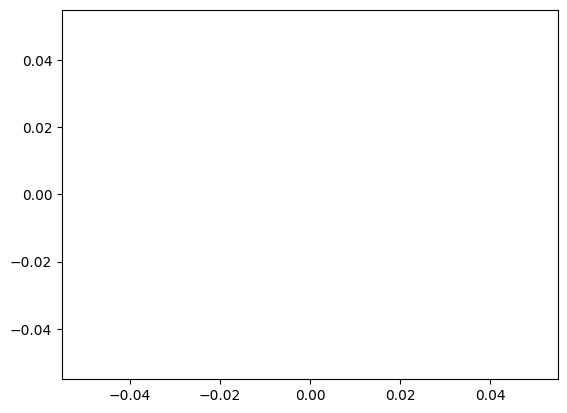

In [ ]:
#plt.plot(lri, lossi)